# exp19 jon_exp19_canvit_fovi_add_ons — IN1k top-1 comparison

Loads `results/jon_exp19_canvit_fovi_add_ons/*_in1k.pt` (one per run), computes per-timestep top-1 accuracy on the 50k ImageNet-1k val set, and shows each run's **unique training params relative to `exp19-baseline-res64-doubleres`** alongside its accuracy curve.

Run names match the wandb run names (= the `RUN_NAME` in each `slurm_nhr/runs/foveated/exps_fovi_add_ons/*.sh` script).

In [1]:
from pathlib import Path
import re
import shlex

import torch
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("/user/henrich1/u25995/jonathan/repos/CanViT-eval/results/jon_exp19_canvit_fovi_add_ons")
SCRIPTS_DIR = Path("/user/henrich1/u25995/jonathan/repos/CanViT-pretrain/slurm_nhr/runs/jon_exp17_19_canvit_foveated/exps_fovi_add_ons")
BASELINE    = "exp19-baseline-res64-doubleres"

## Load results — per-run per-timestep top-1 accuracy

In [9]:
results = {}  # run_name -> list[float] (length T = 10, top-1 acc per glimpse)

for path in sorted(RESULTS_DIR.glob("*_in1k.pt")):
    run = path.name.removesuffix("_in1k.pt")
    r = torch.load(path, map_location="cpu", weights_only=False)
    preds = r["top_k_preds"].long()      # [N, T, 5]
    labels = r["labels"].long()          # [N]
    top1 = (preds[:, :, 0] == labels[:, None]).float().mean(dim=0).tolist()
    results[run] = top1

T = len(next(iter(results.values())))
print(f"Loaded {len(results)} runs, T={T} glimpses each.")
print(f"Baseline present: {BASELINE in results}")

Loaded 22 runs, T=10 glimpses each.
Baseline present: True


## Parse each run's `EXTRA_ARGS` and diff vs the baseline

We tokenize the `EXTRA_ARGS="..."` line in each run's `.sh` script into `{flag: value}`, then compute the symmetric diff against the baseline. The result is a short, human-readable string per run with only the params that distinguish it from `exp19-baseline-res64-doubleres`.

In [10]:
def parse_extra_args(script_path: Path) -> dict:
    text = script_path.read_text()
    m = re.search(r'^EXTRA_ARGS="([^"]*)"', text, re.M)
    if not m:
        return {}
    tokens = shlex.split(m.group(1))
    args, i = {}, 0
    while i < len(tokens):
        tok = tokens[i]
        if tok.startswith("--"):
            if i + 1 < len(tokens) and not tokens[i + 1].startswith("--"):
                args[tok] = tokens[i + 1]
                i += 2
            else:
                args[tok] = True  # boolean flag
                i += 1
        else:
            i += 1
    return args

run_args = {run: parse_extra_args(SCRIPTS_DIR / f"{run}.sh") for run in results}
baseline_args = run_args[BASELINE]
print(f"Baseline ({BASELINE}):")
for k, v in baseline_args.items():
    print(f"  {k} = {v}")

Baseline (exp19-baseline-res64-doubleres):
  --model.patcher-name = foveated
  --model.foveated-patcher.resolution = 64
  --model.foveated-patcher.cart-patch-size = 8
  --model.foveated-patcher.arch-flag = doubleres


In [11]:
_STRIP_PREFIXES = ("--model.foveated-patcher.", "--model.")

def _short(flag: str) -> str:
    for p in _STRIP_PREFIXES:
        if flag.startswith(p):
            return flag[len(p):]
    return flag.removeprefix("--")

def diff_vs_baseline(args: dict) -> list[str]:
    """Return human-readable list of param differences vs baseline.
    
    Format:
        '+k=v'   : flag k added (not in baseline)
        '+k'     : boolean flag k added
        'k: a→b' : flag k present in both, value changed
        '-k'     : flag k removed (only in baseline)
    """
    diffs = []
    for k, v in args.items():
        if k not in baseline_args:
            diffs.append(f"+{_short(k)}" if v is True else f"+{_short(k)}={v}")
        elif baseline_args[k] != v:
            diffs.append(f"{_short(k)}: {baseline_args[k]}→{v}")
    for k in baseline_args:
        if k not in args:
            diffs.append(f"-{_short(k)}")
    return diffs

run_diffs = {run: diff_vs_baseline(args) for run, args in run_args.items()}

## Summary table

Baseline pinned on top. Other runs sorted by final-glimpse accuracy (descending). The `diff` column shows only what's unique to that run relative to the baseline.

In [12]:
rows = []
for run, top1 in results.items():
    diffs = run_diffs.get(run, [])
    diff_str = "  •  ".join(diffs) if diffs else "(BASELINE)"
    row = {"run": run, "diff_vs_baseline": diff_str, "final": top1[-1], "max": max(top1)}
    for t in range(T):
        row[f"t{t}"] = top1[t]
    rows.append(row)

df = pd.DataFrame(rows)
# pin baseline at top, then sort others by final desc
is_base = df["run"].eq(BASELINE)
df = pd.concat([df[is_base], df[~is_base].sort_values("final", ascending=False)], ignore_index=True)

# delta vs baseline (final-glimpse acc)
baseline_final = df.loc[df["run"] == BASELINE, "final"].iloc[0]
df["delta_final"] = df["final"] - baseline_final

ordered_cols = ["run", "diff_vs_baseline", "final", "max", "delta_final"] + [f"t{t}" for t in range(T)]
df = df[ordered_cols]

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)
fmt = {c: "{:+.4f}" if c == "delta_final" else "{:.4f}" for c in ["final", "max", "delta_final"] + [f"t{t}" for t in range(T)]}
df.style.format(fmt).background_gradient(subset=["delta_final"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)

,run,diff_vs_baseline,final,max,delta_final,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9
0,exp19-baseline-res64-doubleres,(BASELINE),0.6390,0.6390,+0.0000,0.5630,0.5956,0.6127,0.6222,0.6286,0.6315,0.6338,0.6359,0.6369,0.6390
1,exp19-film-pos-sigma4,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4,0.6603,0.6603,+0.0213,0.5769,0.6137,0.6294,0.6413,0.6485,0.6521,0.6550,0.6571,0.6590,0.6603
2,exp19-film-pos-sigma16,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=16,0.6531,0.6531,+0.0140,0.5689,0.6057,0.6218,0.6321,0.6402,0.6439,0.6470,0.6496,0.6515,0.6531
3,exp19-coordconv,+conditioning.mode=coordconv,0.6522,0.6522,+0.0132,0.5691,0.6063,0.6236,0.6348,0.6413,0.6448,0.6477,0.6500,0.6513,0.6522
4,exp19-coordconv-mlp768,+conditioning.mode=coordconv • +hidden-dims-patch-embed=768,0.6491,0.6491,+0.0101,0.5609,0.5991,0.6168,0.6294,0.6368,0.6409,0.6429,0.6459,0.6482,0.6491
5,exp19-film-learned512,+conditioning.mode=film • +conditioning.film.input=learned • +conditioning.film.learned-dim=512,0.6481,0.6481,+0.0091,0.5674,0.6035,0.6205,0.6311,0.6379,0.6411,0.6431,0.6457,0.6472,0.6481
6,exp19-film-pos-sigma1,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=1,0.6463,0.6463,+0.0073,0.5654,0.5988,0.6157,0.6269,0.6341,0.6383,0.6407,0.6431,0.6449,0.6463
7,exp19-fixsize722,+fixation-size=722,0.6459,0.6459,+0.0069,0.5735,0.6059,0.6196,0.6296,0.6360,0.6387,0.6418,0.6436,0.6444,0.6459
8,exp19-film-pos-sigma4-mlp768,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4 • +hidden-dims-patch-embed=768,0.6459,0.6459,+0.0069,0.5571,0.5948,0.6141,0.6257,0.6331,0.6376,0.6403,0.6427,0.6440,0.6459
9,exp19-backbone-registers-19,+n-backbone-registers=19,0.6452,0.6452,+0.0061,0.5632,0.5999,0.6159,0.6265,0.6338,0.6369,0.6397,0.6425,0.6434,0.6452


## Accuracy vs glimpse — line plot

Baseline is drawn thick & black. Other runs are coloured. Hover/click in jupyterlab for legend interaction, or just visually scan for differences from the baseline.

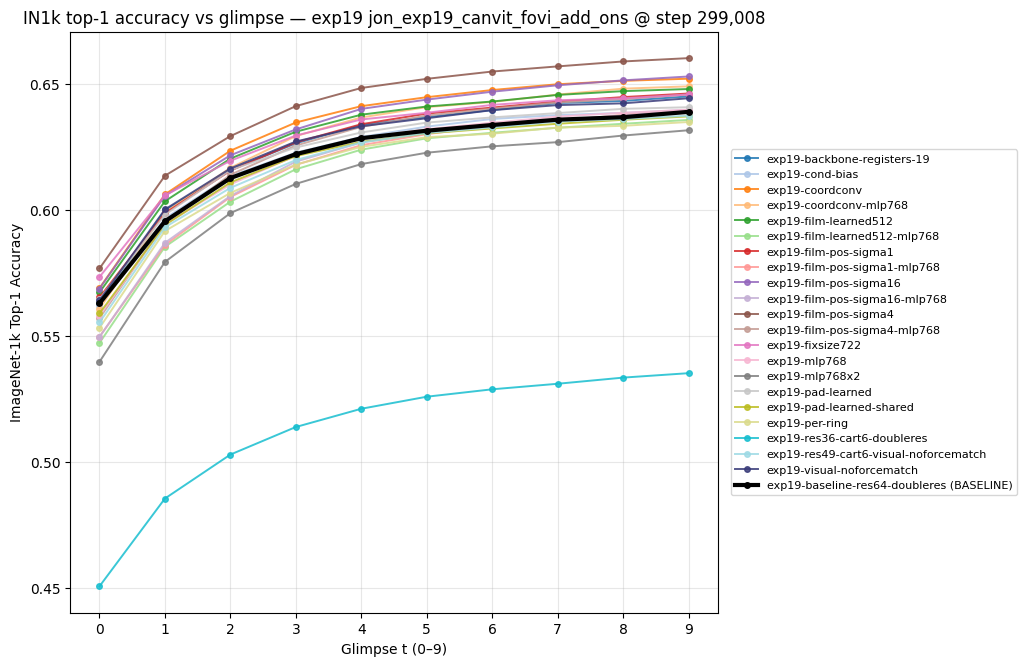

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
ts = list(range(T))

# tab20 gives 20 perceptually distinct colors so curves never repeat
# (we have up to 20 non-baseline runs -> exact fit).
non_baseline = sorted(r for r in results if r != BASELINE)
# tab20 + tab20b = 40 categorical colors; safe up to 40 non-baseline runs.
_palette = [plt.get_cmap("tab20")(i) for i in range(20)] + [plt.get_cmap("tab20b")(i) for i in range(20)]
color_map = {r: _palette[i % len(_palette)] for i, r in enumerate(non_baseline)}

# Non-baseline first, baseline last so it draws on top.
for run in non_baseline + [BASELINE]:
    is_base = run == BASELINE
    ax.plot(
        ts, results[run], marker="o", markersize=4,
        lw=3 if is_base else 1.4,
        alpha=1.0 if is_base else 0.85,
        color="black" if is_base else color_map[run],
        label=f"{run}{' (BASELINE)' if is_base else ''}",
    )

ax.set_xlabel("Glimpse t (0–9)")
ax.set_ylabel("ImageNet-1k Top-1 Accuracy")
ax.set_title("IN1k top-1 accuracy vs glimpse — exp19 jon_exp19_canvit_fovi_add_ons @ step 299,008")
ax.set_xticks(ts)
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, borderaxespad=0)

# Explicit subplots_adjust (legend pushed outside via bbox_to_anchor=1.02).
fig.subplots_adjust(left=0.08, right=0.62, top=0.93, bottom=0.10)
plt.show()

## Delta vs baseline — final-glimpse accuracy

Horizontal bar chart of `final_acc(run) − final_acc(baseline)`. Bars right of zero = better than baseline; left = worse.

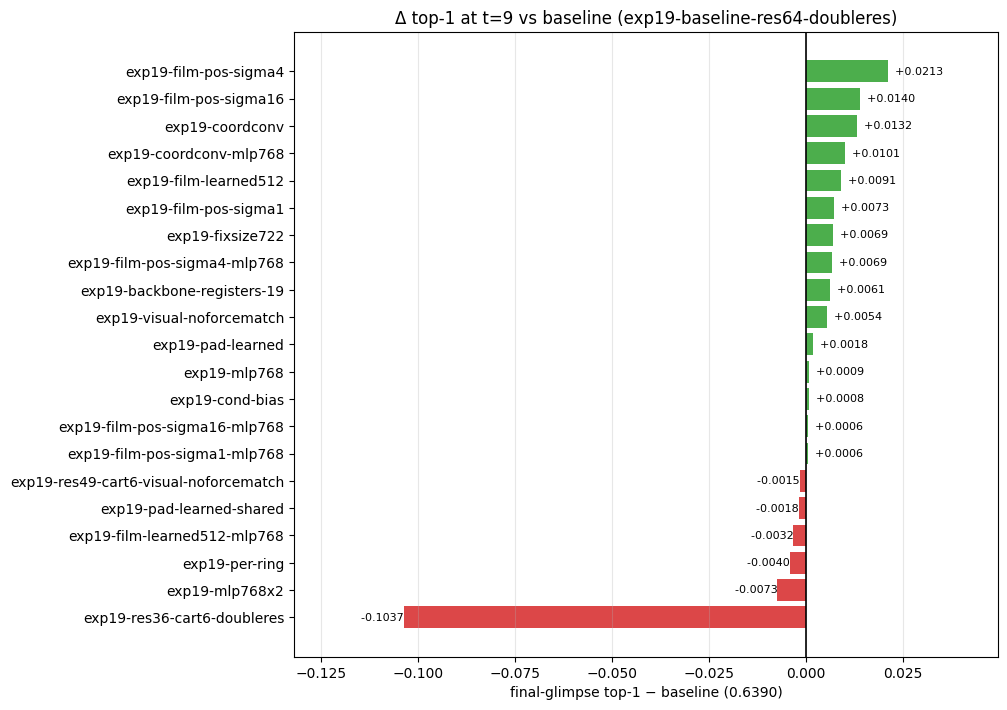

In [14]:
# Self-contained: recompute baseline_final and per-run delta from `results`
# so this cell runs correctly even after a fresh kernel.
baseline_final = results[BASELINE][-1]
deltas = [(r, results[r][-1] - baseline_final) for r in results if r != BASELINE]
deltas.sort(key=lambda x: x[1])
run_names = [r for r, _ in deltas]
delta_vals = [d for _, d in deltas]

# Use INTEGER y-positions everywhere; put run names on as yticklabels.
# Passing a string as the y-arg of ax.text triggers matplotlib's categorical
# unit converter, which on some matplotlib versions returns a numpy array
# (not a scalar) and then errors at draw time ("only 0-dimensional arrays
# can be converted to Python scalars" in text.py: float(convert_yunits(_y))).
y_pos = list(range(len(run_names)))

fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(deltas))))
colors = ["#2ca02c" if d >= 0 else "#d62728" for d in delta_vals]
ax.barh(y_pos, delta_vals, color=colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(run_names)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel(f"final-glimpse top-1 − baseline ({baseline_final:.4f})")
ax.set_title("Δ top-1 at t=9 vs baseline (exp19-baseline-res64-doubleres)")
ax.grid(True, alpha=0.3, axis="x")

# Pad xlim so right-side text labels don't get clipped at the edge.
xmin, xmax = ax.get_xlim()
pad = max(abs(xmin), abs(xmax)) * 0.20
ax.set_xlim(xmin - pad, xmax + pad)

for i, d in zip(y_pos, delta_vals):
    ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=8,
            ha="left" if d >= 0 else "right")

fig.subplots_adjust(left=0.32, right=0.96, top=0.93, bottom=0.08)
plt.show()

# Teacher reconstruction (cosine similarity vs DINOv3)

Loads `results/jon_exp19_canvit_fovi_add_ons/*_recon.pt`. Per-glimpse metrics:
- **`scene_cos_norm`** — canvas patch features vs teacher patch features, standardized
- **`cls_cos_norm`** — recurrent CLS vs teacher CLS, standardized

Same baseline (`exp19-baseline-res64-doubleres`) and same `run_diffs` table reused from the in1k section above.

In [15]:
recon_results = {}  # run -> {scene_cos_norm: [t0..t9], cls_cos_norm: [t0..t9]}
for path in sorted(RESULTS_DIR.glob("*_recon.pt")):
    run = path.name.removesuffix("_recon.pt")
    r = torch.load(path, map_location="cpu", weights_only=False)
    per_t = r["per_timestep"]
    recon_results[run] = {
        "scene_cos_norm": [p["scene_cos_norm"] for p in per_t],
        "cls_cos_norm":   [p["cls_cos_norm"]   for p in per_t],
    }
T_recon = len(next(iter(recon_results.values()))["scene_cos_norm"])
print(f"Loaded {len(recon_results)} recon runs, T={T_recon} glimpses each.")
print(f"Baseline present: {BASELINE in recon_results}")

Loaded 22 recon runs, T=10 glimpses each.
Baseline present: True


## Summary table

Baseline pinned on top; others sorted by `scene_cos_norm @ t=9` (descending). Shows `t=0` and `t=9` for both metrics, with the t=9 deltas vs baseline gradient-coloured red→green.

In [16]:
rows = []
for run in recon_results:
    rr = recon_results[run]
    diffs = run_diffs.get(run, [])
    diff_str = "  •  ".join(diffs) if diffs else "(BASELINE)"
    rows.append({
        "run": run,
        "diff_vs_baseline": diff_str,
        "scene_t0": rr["scene_cos_norm"][0],
        "scene_t9": rr["scene_cos_norm"][-1],
        "cls_t0":   rr["cls_cos_norm"][0],
        "cls_t9":   rr["cls_cos_norm"][-1],
    })

df_recon = pd.DataFrame(rows)
is_base = df_recon["run"].eq(BASELINE)
df_recon = pd.concat(
    [df_recon[is_base], df_recon[~is_base].sort_values("scene_t9", ascending=False)],
    ignore_index=True,
)

bs_scene_t9 = df_recon.loc[df_recon["run"] == BASELINE, "scene_t9"].iloc[0]
bs_cls_t9   = df_recon.loc[df_recon["run"] == BASELINE, "cls_t9"].iloc[0]
df_recon["Δscene_t9"] = df_recon["scene_t9"] - bs_scene_t9
df_recon["Δcls_t9"]   = df_recon["cls_t9"]   - bs_cls_t9

cols = ["run", "diff_vs_baseline", "scene_t0", "scene_t9", "Δscene_t9",
        "cls_t0", "cls_t9", "Δcls_t9"]
df_recon = df_recon[cols]

fmt = {c: ("{:+.4f}" if c.startswith("Δ") else "{:.4f}")
       for c in cols if c not in ("run", "diff_vs_baseline")}
(df_recon.style
    .format(fmt)
    .background_gradient(subset=["Δscene_t9"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)
    .background_gradient(subset=["Δcls_t9"],   cmap="RdYlGn", vmin=-0.05, vmax=0.05))

,run,diff_vs_baseline,scene_t0,scene_t9,Δscene_t9,cls_t0,cls_t9,Δcls_t9
0,exp19-baseline-res64-doubleres,(BASELINE),0.6256,0.7144,+0.0000,0.6369,0.7005,+0.0000
1,exp19-film-pos-sigma4,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4,0.6345,0.7236,+0.0092,0.6469,0.7126,+0.0121
2,exp19-film-pos-sigma16,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=16,0.6318,0.7215,+0.0071,0.6428,0.7086,+0.0081
3,exp19-fixsize722,+fixation-size=722,0.6445,0.7214,+0.0070,0.6461,0.7041,+0.0036
4,exp19-coordconv,+conditioning.mode=coordconv,0.6306,0.7213,+0.0069,0.6414,0.7085,+0.0080
5,exp19-film-pos-sigma4-mlp768,+conditioning.mode=film • +conditioning.film.input=position • +conditioning.film.fourier.num-features=256 • +conditioning.film.fourier.sigma=4 • +hidden-dims-patch-embed=768,0.6258,0.7202,+0.0058,0.6350,0.7048,+0.0043
6,exp19-film-learned512,+conditioning.mode=film • +conditioning.film.input=learned • +conditioning.film.learned-dim=512,0.6308,0.7201,+0.0057,0.6424,0.7061,+0.0057
7,exp19-coordconv-mlp768,+conditioning.mode=coordconv • +hidden-dims-patch-embed=768,0.6226,0.7187,+0.0043,0.6335,0.7045,+0.0041
8,exp19-visual-noforcematch,+sample-cortex=False • +no-force-patches-less-than-matched,0.6271,0.7186,+0.0042,0.6363,0.7014,+0.0009
9,exp19-res49-cart6-visual-noforcematch,resolution: 64→49 • cart-patch-size: 8→6 • +sample-cortex=False • +no-force-patches-less-than-matched,0.6258,0.7184,+0.0040,0.6306,0.6976,-0.0028


## Progression vs glimpse — line plots

Left: `scene_cos_norm` vs t. Right: `cls_cos_norm` vs t. Baseline thick & black, other runs coloured (`tab20`).

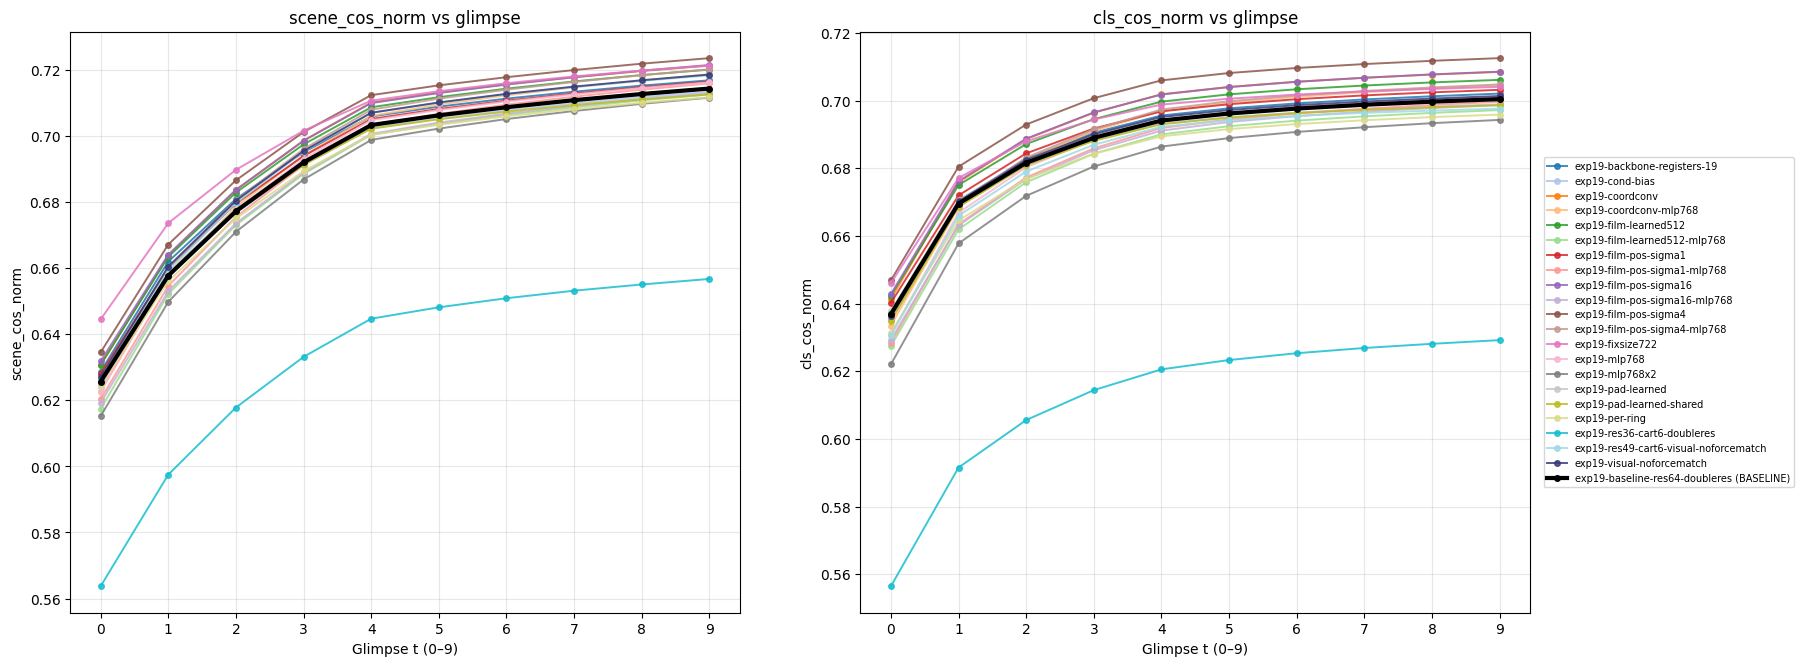

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
ts = list(range(T_recon))

non_baseline_r = sorted(r for r in recon_results if r != BASELINE)
# tab20 + tab20b = 40 categorical colors; safe up to 40 non-baseline runs.
_palette_r = [plt.get_cmap("tab20")(i) for i in range(20)] + [plt.get_cmap("tab20b")(i) for i in range(20)]
color_map_r = {r: _palette_r[i % len(_palette_r)] for i, r in enumerate(non_baseline_r)}

for ax, key, title in [
    (axes[0], "scene_cos_norm", "scene_cos_norm vs glimpse"),
    (axes[1], "cls_cos_norm",   "cls_cos_norm vs glimpse"),
]:
    for run in non_baseline_r + [BASELINE]:
        is_base = run == BASELINE
        ax.plot(
            ts, recon_results[run][key], marker="o", markersize=4,
            lw=3 if is_base else 1.4,
            alpha=1.0 if is_base else 0.85,
            color="black" if is_base else color_map_r[run],
            label=f"{run}{' (BASELINE)' if is_base else ''}",
        )
    ax.set_xlabel("Glimpse t (0–9)")
    ax.set_ylabel(key)
    ax.set_title(title)
    ax.set_xticks(ts)
    ax.grid(True, alpha=0.3)

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, borderaxespad=0)
fig.subplots_adjust(left=0.05, right=0.78, top=0.93, bottom=0.10, wspace=0.18)
plt.show()

## Δ vs baseline at t=9 — horizontal bars

Same idea as the in1k delta plot, separately for the two reconstruction metrics. Green = better than baseline, red = worse. Integer y-positions used to avoid the matplotlib 3.9 categorical-y rendering bug.

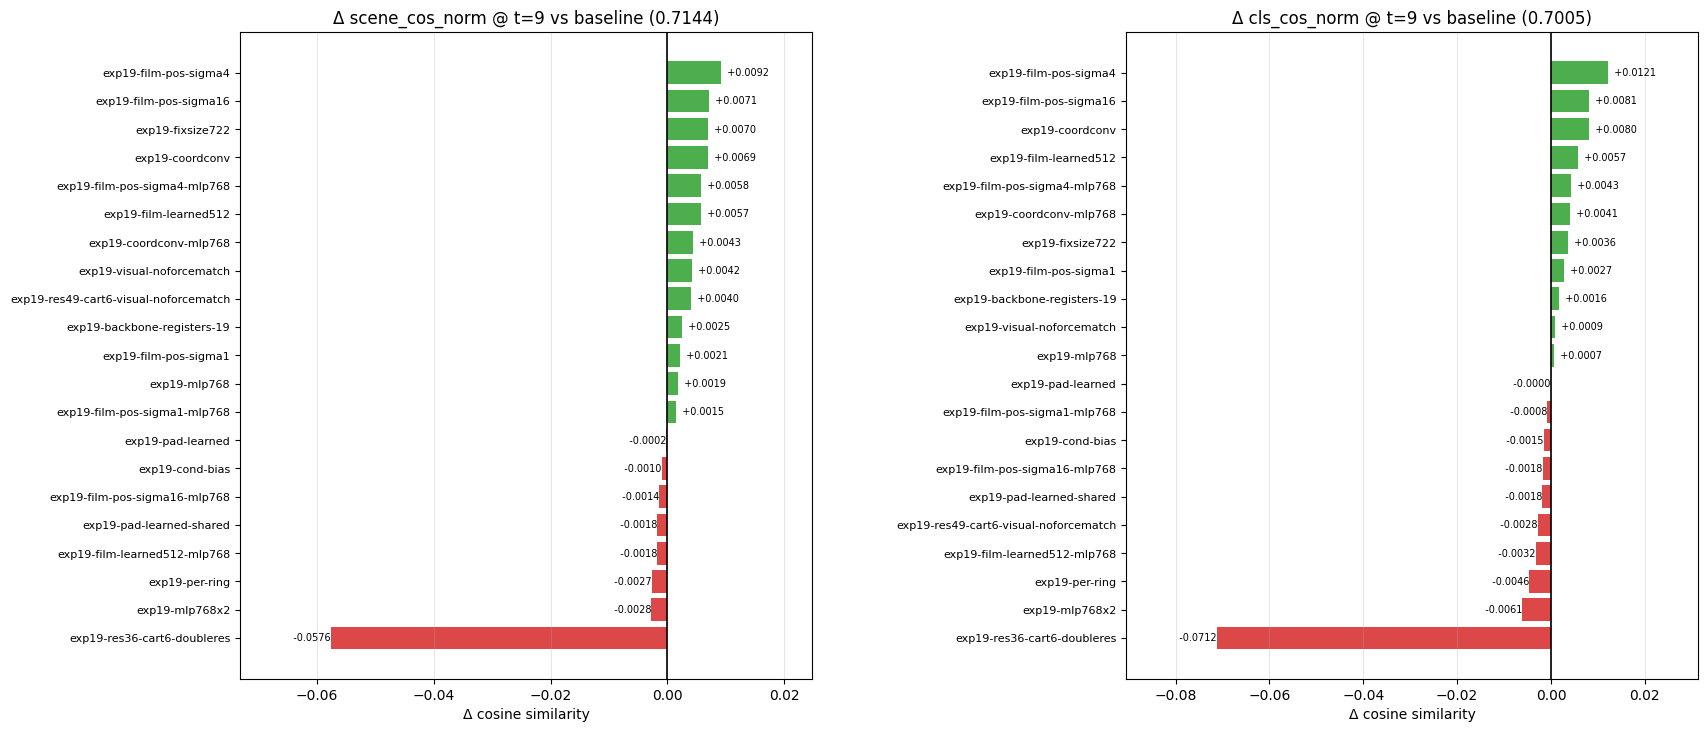

In [18]:
bs_scene = recon_results[BASELINE]["scene_cos_norm"][-1]
bs_cls   = recon_results[BASELINE]["cls_cos_norm"][-1]

scene_deltas = sorted(
    [(r, recon_results[r]["scene_cos_norm"][-1] - bs_scene)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)
cls_deltas = sorted(
    [(r, recon_results[r]["cls_cos_norm"][-1] - bs_cls)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.35 * len(scene_deltas))))

for ax, deltas, title in [
    (axes[0], scene_deltas, f"Δ scene_cos_norm @ t=9 vs baseline ({bs_scene:.4f})"),
    (axes[1], cls_deltas,   f"Δ cls_cos_norm @ t=9 vs baseline ({bs_cls:.4f})"),
]:
    names = [r for r, _ in deltas]
    vals  = [d for _, d in deltas]
    y_pos = list(range(len(names)))
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in vals]
    ax.barh(y_pos, vals, color=colors, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.axvline(0, color="black", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Δ cosine similarity")
    ax.grid(True, alpha=0.3, axis="x")
    xmin, xmax = ax.get_xlim()
    pad = max(abs(xmin), abs(xmax)) * 0.20
    ax.set_xlim(xmin - pad, xmax + pad)
    for i, d in zip(y_pos, vals):
        ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=7,
                ha="left" if d >= 0 else "right")

fig.subplots_adjust(left=0.16, right=0.97, top=0.93, bottom=0.05, wspace=0.55)
plt.show()

## Δ vs baseline at t=0 — first-glimpse view

Same chart as above, but using the t=0 cosine instead of t=9. Shows differences in the *initial* (single full-scene glimpse) representation — useful for separating "better at first-look" from "better after sequence integration".

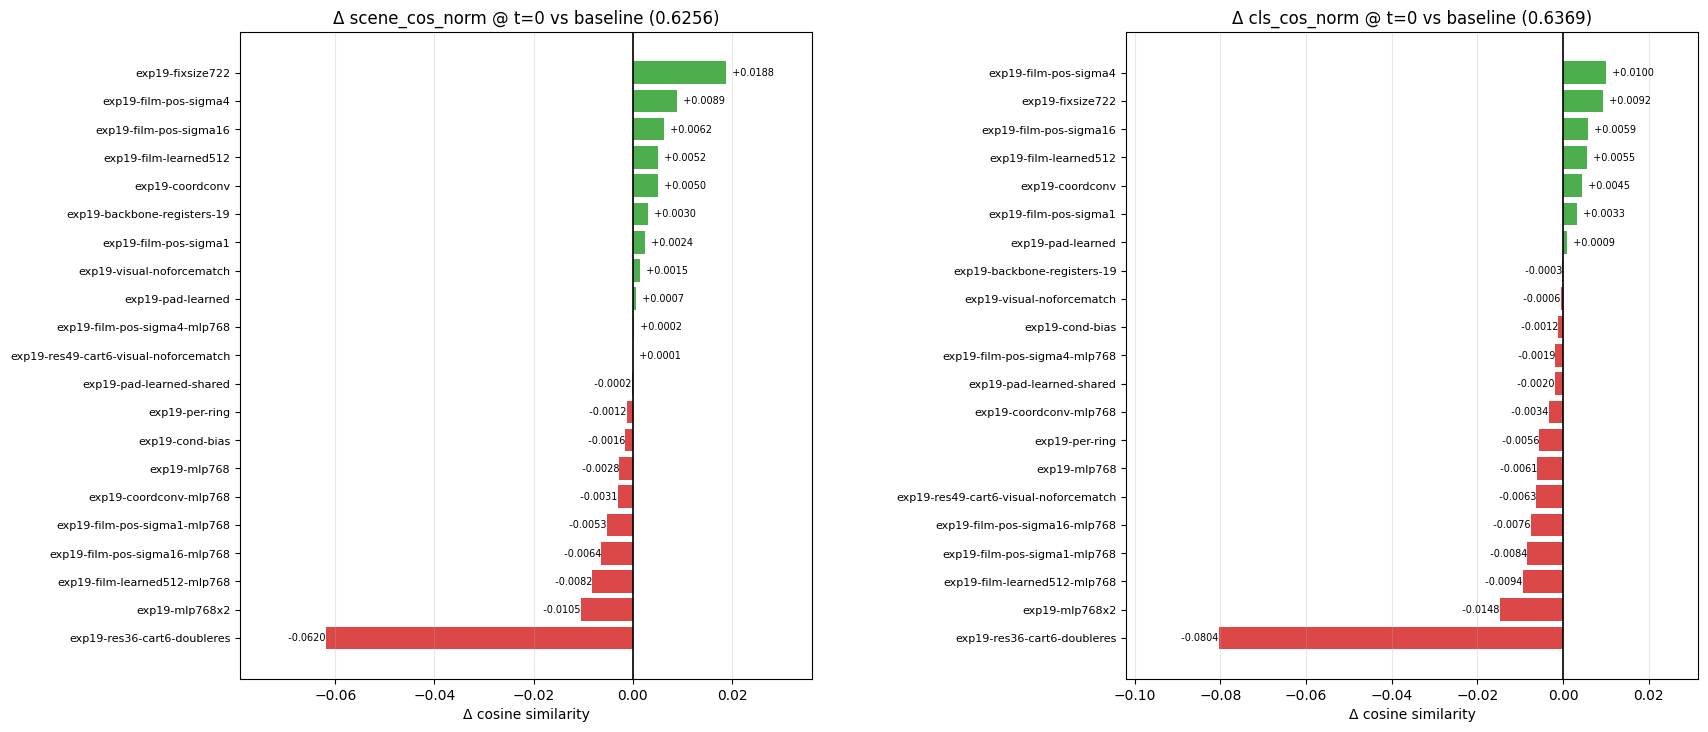

In [19]:
bs_scene_0 = recon_results[BASELINE]["scene_cos_norm"][0]
bs_cls_0   = recon_results[BASELINE]["cls_cos_norm"][0]

scene_deltas_0 = sorted(
    [(r, recon_results[r]["scene_cos_norm"][0] - bs_scene_0)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)
cls_deltas_0 = sorted(
    [(r, recon_results[r]["cls_cos_norm"][0] - bs_cls_0)
     for r in recon_results if r != BASELINE],
    key=lambda x: x[1],
)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.35 * len(scene_deltas_0))))

for ax, deltas, title in [
    (axes[0], scene_deltas_0, f"Δ scene_cos_norm @ t=0 vs baseline ({bs_scene_0:.4f})"),
    (axes[1], cls_deltas_0,   f"Δ cls_cos_norm @ t=0 vs baseline ({bs_cls_0:.4f})"),
]:
    names = [r for r, _ in deltas]
    vals  = [d for _, d in deltas]
    y_pos = list(range(len(names)))
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in vals]
    ax.barh(y_pos, vals, color=colors, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.axvline(0, color="black", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Δ cosine similarity")
    ax.grid(True, alpha=0.3, axis="x")
    xmin, xmax = ax.get_xlim()
    pad = max(abs(xmin), abs(xmax)) * 0.20
    ax.set_xlim(xmin - pad, xmax + pad)
    for i, d in zip(y_pos, vals):
        ax.text(d, i, f"  {d:+.4f}", va="center", fontsize=7,
                ha="left" if d >= 0 else "right")

fig.subplots_adjust(left=0.16, right=0.97, top=0.93, bottom=0.05, wspace=0.55)
plt.show()